### LSE Data Analytics Online Career Accelerator 

# DA301:  Advanced Analytics for Organisational Impact

## Assignment template

### Scenario
You are a data analyst working for Turtle Games, a game manufacturer and retailer. They manufacture and sell their own products, along with sourcing and selling products manufactured by other companies. Their product range includes books, board games, video games and toys. They have a global customer base and have a business objective of improving overall sales performance by utilising customer trends. In particular, Turtle Games wants to understand: 
- how customers accumulate loyalty points (Week 1)
- exploring the structure using decision trees (Week 2)
- exploring clusters in customer behaviour (Week 3)
- can social data (e.g. customer reviews) be used in marketing campaigns (Week 4)
- loading, transforming and visualising data in R (Week 5)
- statistical analysis and modelling in R (Week 6)

# Week 1 assignment: Linear regression using Python
The marketing department of Turtle Games prefers Python for data analysis. As you are fluent in Python, they asked you to assist with data analysis of social media data. The marketing department wants to better understand how users accumulate loyalty points. Therefore, you need to investigate the possible relationships between the loyalty points, age, remuneration, and spending scores. Note that you will use this data set in future modules as well and it is, therefore, strongly encouraged to first clean the data as per provided guidelines and then save a copy of the clean data for future use.

## Instructions
1. Load and explore the data.
    1. Create a new DataFrame (e.g. reviews).
    2. Sense-check the DataFrame.
    3. Determine if there are any missing values in the DataFrame.
    4. Create a summary of the descriptive statistics.
2. Remove redundant columns (`language` and `platform`).
3. Change column headings to names that are easier to reference (e.g. `renumeration` and `spending_score`).
4. Save a copy of the clean DataFrame as a CSV file. Import the file to sense-check.
5. Use linear regression and goodness of fit metrics to evaluate possible linear relationships between loyalty points and age/renumeration/spending scores to determine whether these can be used to predict the loyalty points.
    1. Specify the independent and dependent variables.
    2. Create the OLS model.
    3. Extract the estimated parameters, standard errors, and predicted values.
    4. Generate the regression table based on the X coefficient and constant values.
    5. Plot the linear regression and add a regression line.
6. Include your insights and observations.

## 1. Load and explore the data

In [12]:
# Import all the necessary packages.
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.stats.api as sms
import sklearn
import matplotlib.pyplot as plt

from sklearn import linear_model
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LinearRegression
from statsmodels.formula.api import ols

In [13]:
# Load the CSV file(s) as reviews.
reviews = pd.read_csv(r'c:\Users\james\LSE Data Analytics/LSE Data Analytics Course 3/Assignment/turtle_reviews.csv')

# View the DataFrame.
reviews.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [16]:
# Any missing values?
reviews.isnull().sum()

gender                    0
age                       0
remuneration (k£)         0
spending_score (1-100)    0
loyalty_points            0
education                 0
language                  0
platform                  0
product                   0
review                    0
summary                   0
dtype: int64

In [18]:
# Explore the data.
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [20]:
# Basic descriptive statistics.
reviews.describe()

,age,remuneration (k£),spending_score (1-100),loyalty_points,product
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,39.495000,48.079060,50.000000,1578.032000,4320.521500
std,13.573212,23.123984,26.094702,1283.239705,3148.938839
min,17.000000,12.300000,1.000000,25.000000,107.000000
25%,29.000000,30.340000,32.000000,772.000000,1589.250000
50%,38.000000,47.150000,50.000000,1276.000000,3624.000000
75%,49.000000,63.960000,73.000000,1751.250000,6654.000000
max,72.000000,112.340000,99.000000,6847.000000,11086.000000


## 2. Drop columns

In [23]:
# Drop unnecessary columns.
reviews.drop(['language', 'platform'], axis=1, inplace=True)

In [25]:
# View column names.
reviews.columns

Index(['gender', 'age', 'remuneration (k£)', 'spending_score (1-100)',
       'loyalty_points', 'education', 'product', 'review', 'summary'],
      dtype='object')

## 3. Rename columns

In [28]:
# Rename the column headers.
reviews.rename(columns={'remuneration (k£)': 'remuneration', 'spending_score (1-100)': 'spending_score'}, inplace=True)


# View column names.
reviews.columns

Index(['gender', 'age', 'remuneration', 'spending_score', 'loyalty_points',
       'education', 'product', 'review', 'summary'],
      dtype='object')

## 4. Save the DataFrame as a CSV file

In [31]:
# Create a CSV file as output.
reviews.to_csv('turtle_reviews_new.csv', index=False)

In [33]:
# Import new CSV file with Pandas.
reviews = pd.read_csv(r'c:\Users\james\LSE Data Analytics/LSE Data Analytics Course 3/Assignment/turtle_reviews_new.csv')

# View DataFrame.
reviews.head()

,gender,age,remuneration,spending_score,loyalty_points,education,product,review,summary
0,Male,18,12.30,39,210,graduate,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,291,As my review of GF9's previous screens these w...,Money trap


## 5. Linear regression

### 5a) spending vs loyalty

In [37]:
# Define independent variable.
y = reviews['loyalty_points']

# Define dependent variable.
x = reviews[['spending_score']]

# Create model
lin_spending = LinearRegression()
lin_spending.fit(x,y)

LinearRegression()

In [39]:
# Extract the value of R-squared
print("R-squared: ", lin_spending.score(x, y))

# Extract the estimated parameters.
print("Intercept:", lin_spending.intercept_)
print("Coefficients:")
list(zip(x, lin_spending.coef_))

R-squared:  0.4520008865838909
Intercept: -75.05266293364707
Coefficients:


[('spending_score', 33.06169325867294)]

In [41]:
# Extract the standard errors.
x_reviews = sm.add_constant(x)
model = sm.OLS(y, x_reviews).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.452
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     1648.
Date:                Thu, 24 Jul 2025   Prob (F-statistic):          2.92e-263
Time:                        13:52:46   Log-Likelihood:                -16550.
No. Observations:                2000   AIC:                         3.310e+04
Df Residuals:                    1998   BIC:                         3.312e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -75.0527     45.931     -1.

In [43]:
# Extract the predicted values.
lin_spending.predict(x)

array([1214.35337415, 2602.94449102,  123.31749662, ..., 2933.56142361,
        453.93442921,  189.44088314])

In [92]:
# Set the X coefficient and the constant to generate the regression table.
predicted_loyalty_s = lin_spending.predict(x)

# View the output.
print(predicted_loyalty_s)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- age
Feature names seen at fit time, yet now missing:
- spending_score


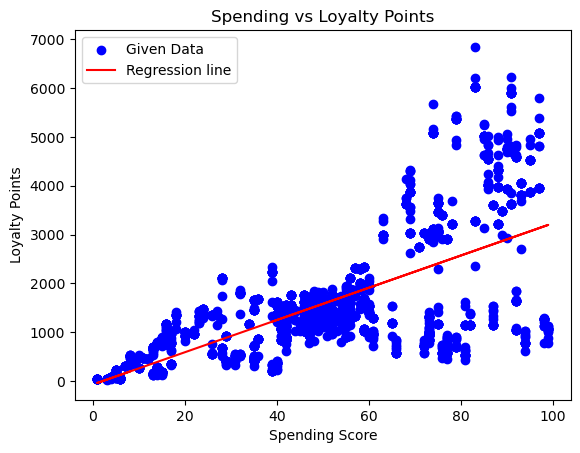

In [48]:
# Plot the graph with a regression line.
plt.scatter(x, y, color='blue', label='Given Data')
plt.plot(x, predicted_loyalty_s, color='red', label='Regression line')
plt.xlabel('Spending Score')
plt.ylabel('Loyalty Points')
plt.legend()
plt.title('Spending vs Loyalty Points')
plt.show()

### 5b) renumeration vs loyalty

In [51]:
# Define independent variable.
y = reviews['loyalty_points']

# Define dependent variable.
x = reviews[['remuneration']]

# Create model
lin_remuneration = LinearRegression()
lin_remuneration.fit(x,y)

LinearRegression()

In [53]:
# Extract the value of R-squared
print("R-squared: ", lin_remuneration.score(x, y))

# Extract the estimated parameters.
print("Intercept:", lin_remuneration.intercept_)
print("Coefficients:")
list(zip(x, lin_remuneration.coef_))

R-squared:  0.3795357732793634
Intercept: -65.68651279500432
Coefficients:


[('remuneration', 34.1878254856689)]

In [55]:
# Extract the standard errors.
x_reviews = sm.add_constant(x)
model = sm.OLS(y, x_reviews).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.380
Model:                            OLS   Adj. R-squared:                  0.379
Method:                 Least Squares   F-statistic:                     1222.
Date:                Thu, 24 Jul 2025   Prob (F-statistic):          2.43e-209
Time:                        13:52:52   Log-Likelihood:                -16674.
No. Observations:                2000   AIC:                         3.335e+04
Df Residuals:                    1998   BIC:                         3.336e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const          -65.6865     52.171     -1.259   

In [57]:
# Extract the predicted values.
lin_remuneration.predict(x)

array([ 354.82374068,  354.82374068,  382.85775758, ..., 3102.15739671,
       3298.39551499, 3102.15739671])

In [59]:
# Set the X coefficient and the constant to generate the regression table.
predicted_loyalty_r = lin_remuneration.predict(x)

# View the output.
print(f"Loyalty_Points = {lin_remuneration.intercept_:.2f} + ({lin_remuneration.coef_[0]:.2f} * Remuneration_Score)")

print(predicted_loyalty_r)

Loyalty_Points = -65.69 + (34.19 * Remuneration_Score)
[ 354.82374068  354.82374068  382.85775758 ... 3102.15739671 3298.39551499
 3102.15739671]


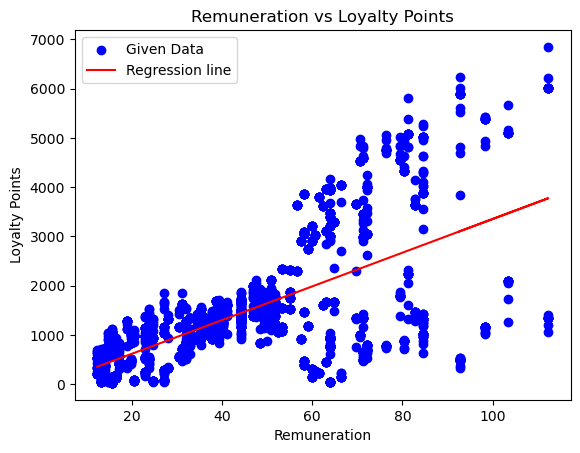

In [61]:
# Plot the graph with a regression line.
plt.scatter(x, y, color='blue', label='Given Data')
plt.plot(x, predicted_loyalty_r, color='red', label='Regression line')
plt.xlabel('Remuneration')
plt.ylabel('Loyalty Points')
plt.legend()
plt.title('Remuneration vs Loyalty Points')
plt.show()

### 5c) age vs loyalty

In [64]:
# Define independent variable.
y = reviews['loyalty_points']

# Define dependent variable.
x = reviews[['age']]

# Create model
lin_age = LinearRegression()
lin_age.fit(x,y)

LinearRegression()

In [66]:
# Extract the value of R-squared
print("R-squared: ", lin_age.score(x, y))

# Extract the estimated parameters.
print("Intercept:", lin_age.intercept_)
print("Coefficients:")
list(zip(x, lin_age.coef_))

R-squared:  0.0018015480437203468
Intercept: 1736.517739399063
Coefficients:


[('age', -4.012805149995269)]

In [68]:
# Extract the standard errors.
x_reviews = sm.add_constant(x)
model = sm.OLS(y, x_reviews).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.606
Date:                Thu, 24 Jul 2025   Prob (F-statistic):             0.0577
Time:                        13:52:56   Log-Likelihood:                -17150.
No. Observations:                2000   AIC:                         3.430e+04
Df Residuals:                    1998   BIC:                         3.431e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1736.5177     88.249     19.678      0.0

In [70]:
# Extract the predicted values.
lin_age.predict(x)

array([1664.2872467 , 1644.22322095, 1648.2360261 , ..., 1600.0823643 ,
       1600.0823643 , 1608.1079746 ])

In [72]:
# Set the X coefficient and the constant to generate the regression table.
predicted_loyalty_a = lin_age.predict(x)

# View the output.
print(f"Loyalty_Points = {lin_age.intercept_:.2f} + ({lin_age.coef_[0]:.2f} * Age)")

print(predicted_loyalty_a)

Loyalty_Points = 1736.52 + (-4.01 * Age)
[1664.2872467  1644.22322095 1648.2360261  ... 1600.0823643  1600.0823643
 1608.1079746 ]


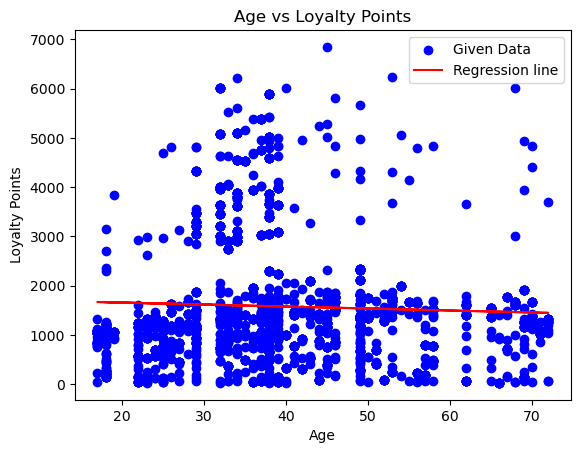

In [74]:
# Plot graph with regression line.
# Plot the graph with a regression line.
plt.scatter(x, y, color='blue', label='Given Data')
plt.plot(x, predicted_loyalty_a, color='red', label='Regression line')
plt.xlabel('Age')
plt.ylabel('Loyalty Points')
plt.legend()
plt.title('Age vs Loyalty Points')
plt.show()

In [76]:
reviews['age_squared'] = reviews['age'] ** 2

In [78]:
X_quad = reviews[['age', 'age_squared']]
y = reviews['loyalty_points']

model_quad = LinearRegression()
model_quad.fit(X_quad, y)

LinearRegression()

In [80]:
print("Intercept:", model_quad.intercept_)
print("Coefficients:", list(zip(X_quad.columns, model_quad.coef_)))

Intercept: -394.7406733325222
Coefficients: [('age', 105.24353762761194), ('age_squared', -1.252194441652649)]


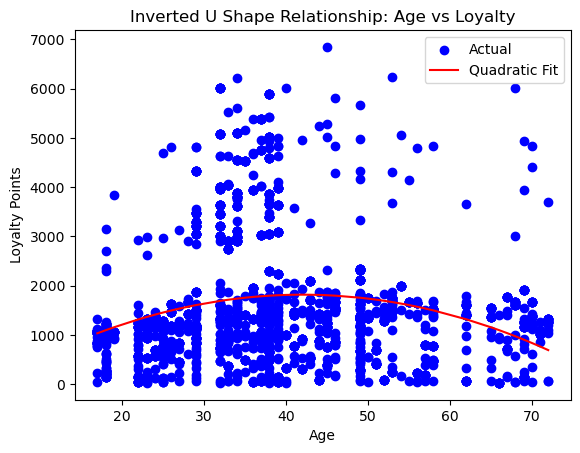

In [82]:
sorted_df = reviews.sort_values('age')
X_plot = sorted_df[['age', 'age_squared']]
y_pred = model_quad.predict(X_plot)

plt.scatter(reviews['age'], y, label='Actual', color='blue')
plt.plot(sorted_df['age'], y_pred, label='Quadratic Fit', color='red')
plt.xlabel('Age')
plt.ylabel('Loyalty Points')
plt.title('Inverted U Shape Relationship: Age vs Loyalty')
plt.legend()
plt.show()

In [84]:
# Check the goodness of fit of the new inverse square age
# Inverse Square Age and make new column
reviews['age_inv_squared'] = 1 / (reviews['age'] ** 2)

# Redefine
X_inv_sq = reviews[['age_inv_squared']]
y = reviews['loyalty_points']

# Fit the model
model_inv_sq = LinearRegression()
model_inv_sq.fit(X_inv_sq, y)

# Get R-squared
r_squared_inv_sq = model_inv_sq.score(X_inv_sq, y)
print("R-squared for inverse squared age model:", r_squared_inv_sq)

R-squared for inverse squared age model: 0.014529505823935307


In [86]:
X_sm = sm.add_constant(X_quad)
model_sm = sm.OLS(y, X_sm).fit()
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:         loyalty_points   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.047
Method:                 Least Squares   F-statistic:                     50.63
Date:                Thu, 24 Jul 2025   Prob (F-statistic):           3.55e-22
Time:                        13:53:02   Log-Likelihood:                -17102.
No. Observations:                2000   AIC:                         3.421e+04
Df Residuals:                    1997   BIC:                         3.423e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -394.7407    232.431     -1.698      

## 6. Observations and insights

***Your observations here...***






- Remuneration and age have a positive relationship with Loyalty Points.
- Spending has a slightly better fit / R-Squared value (0.45) vs remuneration (0.34).
- Remuneration has a slightly higher coefficient than age 34 vs 33 - meaning a singular increase in remuneration will lead to slightly more Loyalty Points
- Age can be modelled with an inverse square relationship with Loyalty Points

# Week 2 assignment: Exploring the structure using decision trees.

The team wants you to use decision trees to attempt to better understand the structure found in the data. You need to grow and prune a decision tree regressor and then visualise and interpret the output.
Make sure to comment on the potential usefulness in decision-making processes and your observations regarding the model.

## Instructions
1. Prepare the data for creating your decision tree. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame with the appropriate columns.
        1. Specify that loyalty points is the target variable (Y) and should be excluded from your input data.
        2. Specify X for the independent variables and y as the dependent variable. Therefore, df\[cols\] will be the independent variables and the column containing loyalty points the dependent variable.
        3. Explore the new DataFrame. 
2. Split the data set into a train and test sets for both X and y at a 70:30 ratio. As previously, random_state=42.
3. Create a decision tree regressor to explore the impact of other features on the loyalty points.
    1. Import the DecisionTreeRegressor class from the sklearn.tree library. 
    2. Create a variable (e.g. regressor) to store the DecisionTreeRegressor() class. (As previously, random_state=42.).
    3. Fit the regressor object to the data set with the fit() function.
    4. Remember to prune your tree using basic pruning strategies and compare the performance before and after applying the pruning strategy.
    5. Plot the final decision tree.
4. Fit a final model and interpret the output.
    1. Justify your selection of pruning strategy implemented and interpret the output.
    2. Evaluate the usefulness of the obtained result and interpret the tree and how it could be used to inform business decisions in the organisation.
5. Summarise (150–200 words) the most important business insights, anything you would like to explore further, and suggested future actions.
 
Back up your work to a safe location. This will allow you to revert to a previous state in the case of making a mistake in the code or deleting a section by mistake. (A simple way of doing this is to save or email a compressed version to yourself at frequent intervals.)


## 1. Load and prepare the data

In [225]:
# Import all the necessary packages
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor, plot_tree 
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import warnings
import matplotlib.pyplot as plt

# Settings for the notebook.
warnings.filterwarnings("ignore")
plt.rcParams['figure.figsize'] = [15, 10]

In [227]:
# Create your new DataFrame.
df = pd.read_csv(r'c:\Users\james\LSE Data Analytics/LSE Data Analytics Course 3/Assignment/turtle_reviews.csv')
df2 = df.copy()

In [229]:
df2.drop(['review', 'summary', 'product', 'language'], axis=1, inplace=True)

In [231]:
# Specify Y.
y = df2['loyalty_points']
# Specify X.
X = df2.drop(columns=['loyalty_points'])

In [233]:
# Review X and Y.
X.head(), y.head()

(   gender  age  remuneration (k£)  spending_score (1-100) education platform
 0    Male   18              12.30                      39  graduate      Web
 1    Male   23              12.30                      81  graduate      Web
 2  Female   22              13.12                       6  graduate      Web
 3  Female   25              13.12                      77  graduate      Web
 4  Female   33              13.94                      40  graduate      Web,
 0    210
 1    524
 2     40
 3    562
 4    366
 Name: loyalty_points, dtype: int64)

## 2. Create train and test data sets.

In [236]:
# Split the data into test and train data.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [238]:
# Make categories fit model
X_train['gender'] = X_train['gender'].map({'Male': 0, 'Female': 1})
X_train['education'] = X_train['education'].astype('category').cat.codes
X_train['platform'] = X_train['platform'].astype('category').cat.codes

X_test['gender'] = X_test['gender'].map({'Male': 0, 'Female': 1})
X_test['education'] = X_test['education'].astype('category').cat.codes
X_test['platform'] = X_test['platform'].astype('category').cat.codes

## 3. Create Decision tree regressor

In [241]:
# Create your decision tree regressor.
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [243]:
# Evaluate the model.
from sklearn.metrics import mean_squared_error, r2_score
y_pred = regressor.predict(X_test)
print("R² Score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R² Score: 0.9949378984321586
MSE: 8199.576666666666


In [245]:
# Prune the model.
pruned_regressor = DecisionTreeRegressor(max_depth=5, random_state=42)
pruned_regressor.fit(X_train, y_train)

y_pred_pruned = pruned_regressor.predict(X_test)
print("Pruned R² Score:", r2_score(y_test, y_pred_pruned))

Pruned R² Score: 0.9567099046782617


## 4. Fit and plot final model.

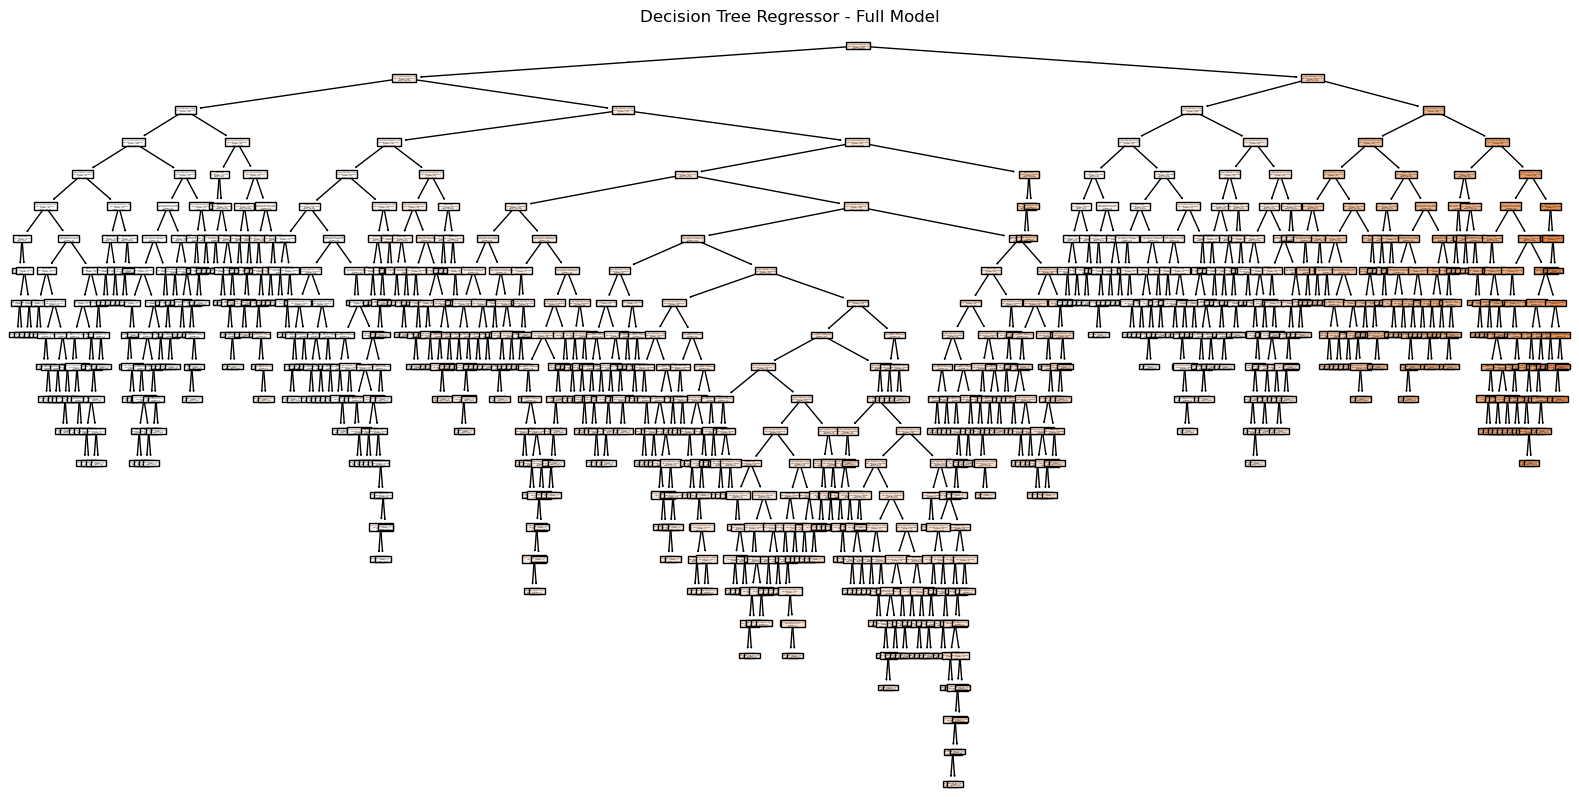

In [250]:
# Fit and plot final model.
plt.figure(figsize=(20, 10))
plot_tree(regressor, feature_names=X.columns, filled=True)
plt.title("Decision Tree Regressor - Full Model")
plt.show()

In [294]:
# ME: PRUNE
regressor = DecisionTreeRegressor(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                      random_state=42)

In [255]:
y_pred = regressor.predict(X_test)
print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R²: 0.9566432650505238
MSE: 70229.10691738166


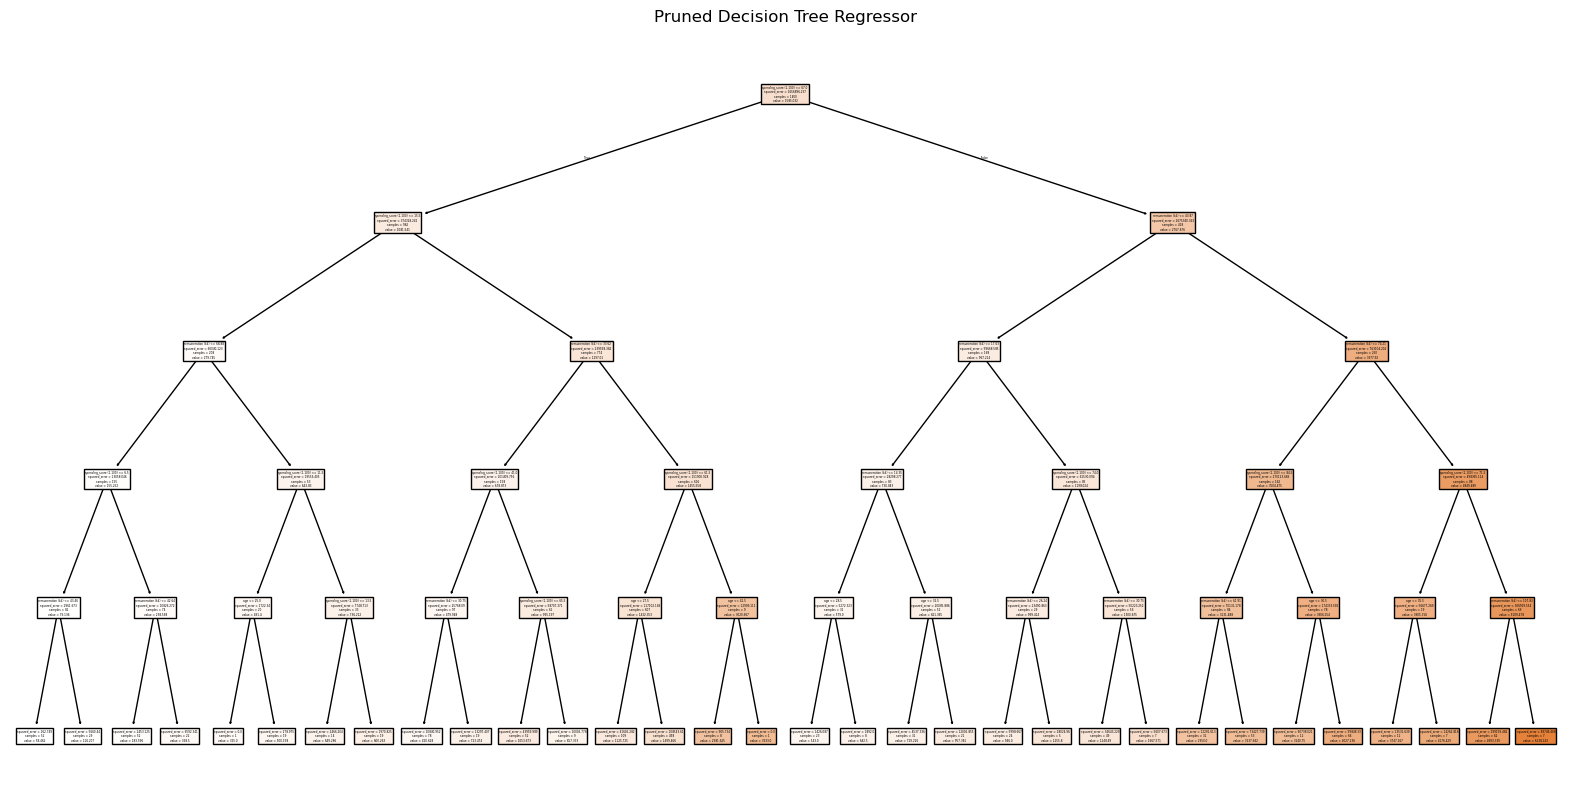

In [257]:
plt.figure(figsize=(20, 10))
plot_tree(pruned_regressor, feature_names=X_train.columns, filled=True)
plt.title("Pruned Decision Tree Regressor")
plt.show()

In [292]:
# ME: PRUNE AGAIN
extra_pruned_regressor = DecisionTreeRegressor(
    max_depth=3,              # Shallower tree
    min_samples_split=20,     # More samples needed to split
    min_samples_leaf=10,      # Leaves must have more samples
    random_state=42
)

extra_pruned_regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=10, min_samples_split=20,
                      random_state=42)

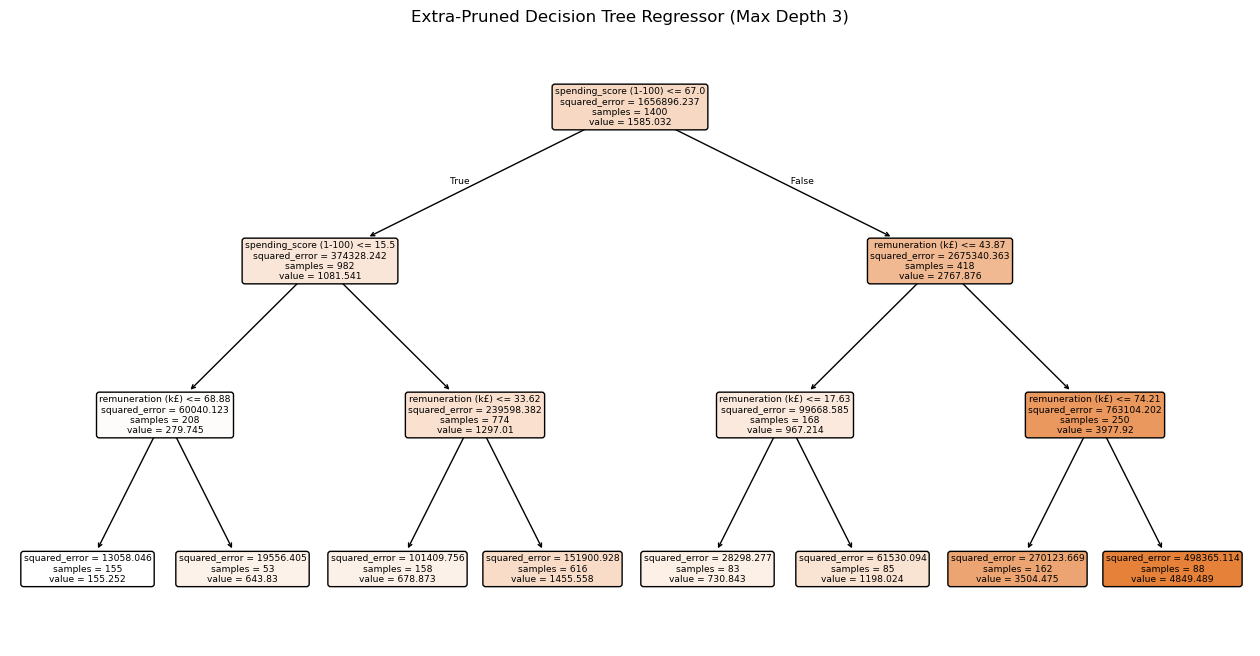

In [286]:
plt.figure(figsize=(16, 8))
plot_tree(extra_pruned_regressor, feature_names=X_train.columns, filled=True, rounded=True)
plt.title("Extra-Pruned Decision Tree Regressor (Max Depth 3)")
plt.show()

In [290]:
# ME: Compare full and pruned tree

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error

# 1. Train original (unpruned) tree
full_tree = DecisionTreeRegressor(random_state=42)
full_tree.fit(X_train, y_train)
full_preds = full_tree.predict(X_test)

# 2. Train extra-pruned tree
pruned_tree = DecisionTreeRegressor(
    max_depth=3,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)
pruned_tree.fit(X_train, y_train)
pruned_preds = pruned_tree.predict(X_test)

# 3. Compare performance
print("=== Full Tree Performance ===")
print("R² Score:", r2_score(y_test, full_preds))
print("MSE:", mean_squared_error(y_test, full_preds))

print("\n=== Extra-Pruned Tree Performance ===")
print("R² Score:", r2_score(y_test, pruned_preds))
print("MSE:", mean_squared_error(y_test, pruned_preds))

=== Full Tree Performance ===
R² Score: 0.9949378984321586
MSE: 8199.576666666666

=== Extra-Pruned Tree Performance ===
R² Score: 0.9148271803581075
MSE: 137962.67325147352


## 5. Discuss: Insights and observations

***Your observations here...***

- Customers that have higher income and spending we can predict to have higher loyalty points
- We predict that there are customer profiles with one of low spending or low remuneration - but high of the other - that will still have a large amount of loyalty points

# Week 3 assignment: Clustering with *k*-means using Python

The marketing department also wants to better understand the usefulness of renumeration and spending scores but do not know where to begin. You are tasked to identify groups within the customer base that can be used to target specific market segments. Use *k*-means clustering to identify the optimal number of clusters and then apply and plot the data using the created segments.

## Instructions
1. Prepare the data for clustering. 
    1. Import the CSV file you have prepared in Week 1.
    2. Create a new DataFrame (e.g. `df3`) containing the `renumeration` and `spending_score` columns.
    3. Explore the new DataFrame. 
2. Plot the renumeration versus spending score.
    1. Create a scatterplot.
    2. Create a pairplot.
3. Use the Silhouette and Elbow methods to determine the optimal number of clusters for *k*-means clustering.
    1. Plot both methods and explain how you determine the number of clusters to use.
    2. Add titles and legends to the plot.
4. Evaluate the usefulness of at least three values for *k* based on insights from the Elbow and Silhoutte methods.
    1. Plot the predicted *k*-means.
    2. Explain which value might give you the best clustering.
5. Fit a final model using your selected value for *k*.
    1. Justify your selection and comment on the respective cluster sizes of your final solution.
    2. Check the number of observations per predicted class.
6. Plot the clusters and interpret the model.

## 1. Load and explore the data

In [96]:
# Import necessary libraries.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score
from scipy.spatial.distance import cdist

import warnings
warnings.filterwarnings('ignore')

In [97]:
# Load the CSV file(s) as df2.
df3 = pd.read_csv(r'c:\Users\james\LSE Data Analytics/LSE Data Analytics Course 3/Assignment/turtle_reviews.csv')[['remuneration (k£)', 'spending_score (1-100)']]
df3.rename(columns={'remuneration (k£)': 'remuneration', 'spending_score (1-100)': 'spending_score'}, inplace=True)

# View DataFrame.
df3.head()

,remuneration,spending_score
0,12.30,39
1,12.30,81
2,13.12,6
3,13.12,77
4,13.94,40


In [100]:
# Explore the data.
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   remuneration    2000 non-null   float64
 1   spending_score  2000 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 31.4 KB


In [102]:
# Descriptive statistics.
df3.describe()

,remuneration,spending_score
count,2000.000000,2000.000000
mean,48.079060,50.000000
std,23.123984,26.094702
min,12.300000,1.000000
25%,30.340000,32.000000
50%,47.150000,50.000000
75%,63.960000,73.000000
max,112.340000,99.000000


## 2. Plot

<Axes: xlabel='remuneration', ylabel='spending_score'>

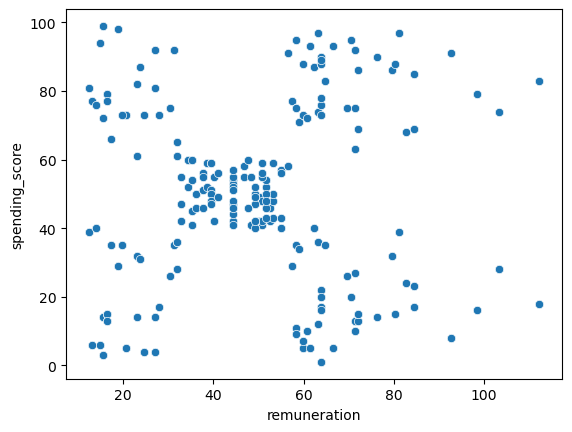

In [105]:
# Create a scatterplot with Seaborn.
sns.scatterplot(x='remuneration', y='spending_score', data=df3)

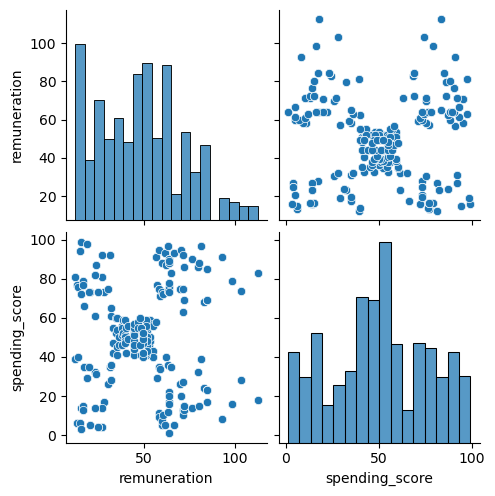

In [107]:
# Create a pairplot with Seaborn.
sns.pairplot(df3)

## 3. Elbow and silhoutte methods

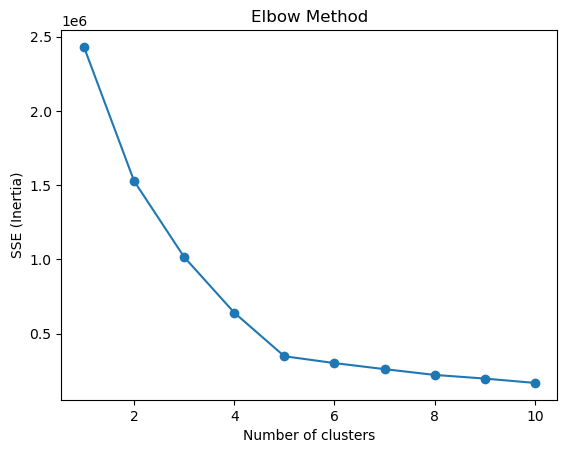

In [109]:
# Determine the number of clusters: Elbow method.
sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df3)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')
plt.show()

In [112]:
# Determine the number of clusters: Silhouette method.
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df3)
    score = silhouette_score(df3, labels)
    print(f'Silhouette score for k={k}: {score:.3f}')

Silhouette score for k=2: 0.326
Silhouette score for k=3: 0.448
Silhouette score for k=4: 0.509
Silhouette score for k=5: 0.583
Silhouette score for k=6: 0.561
Silhouette score for k=7: 0.535
Silhouette score for k=8: 0.524
Silhouette score for k=9: 0.520
Silhouette score for k=10: 0.461


## 4. Evaluate k-means model at different values of *k*

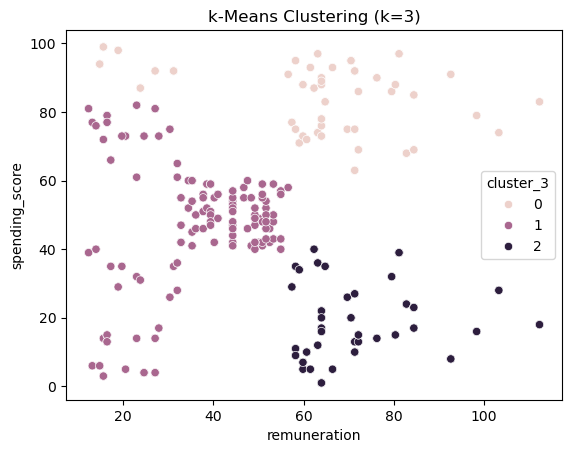

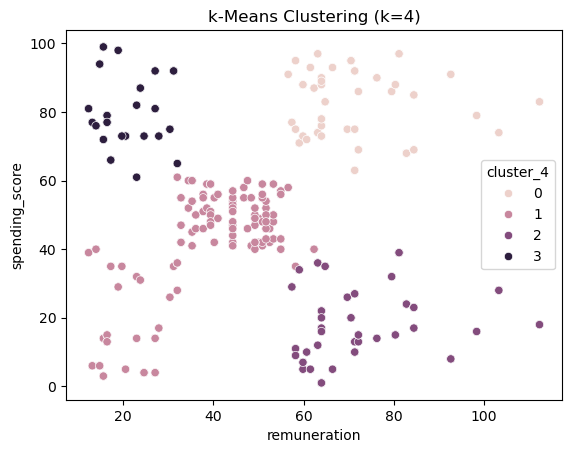

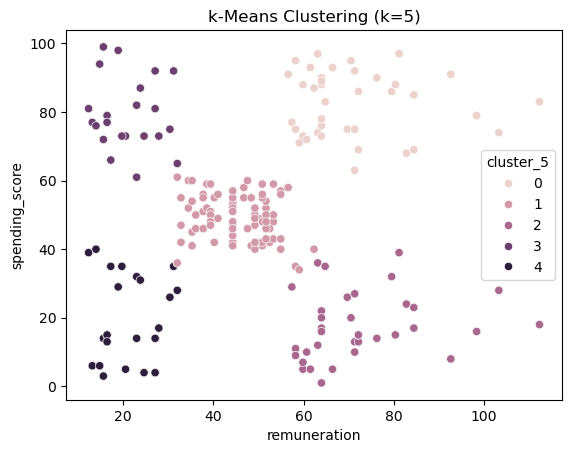

In [115]:
for k in [3, 4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    df3[f'cluster_{k}'] = kmeans.fit_predict(df3)
    sns.scatterplot(x='remuneration', y='spending_score', hue=f'cluster_{k}', data=df3)
    plt.title(f'k-Means Clustering (k={k})')
    plt.show()

## 5. Fit final model and justify your choice

In [130]:
# We chose 5 clusters due to highest silhouette score and it providing the best segmentation of customers
best_k = 5
kmeans_final = KMeans(n_clusters=best_k, random_state=42)
df3['final_cluster'] = kmeans_final.fit_predict(df3)

In [125]:
# Check the number of observations per predicted class.
df3['final_cluster'].value_counts().sort_index()

final_cluster
0    356
1    774
2    330
3    269
4    271
Name: count, dtype: int64

## 6. Plot and interpret the clusters

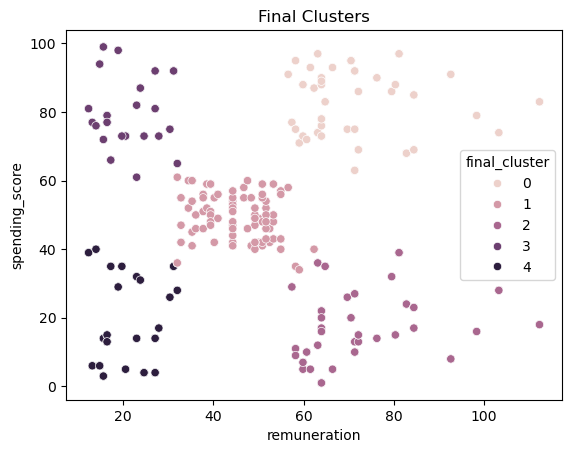

final_cluster
1    774
0    356
2    330
4    271
3    269
Name: count, dtype: int64

In [128]:
# Visualising the clusters.
sns.scatterplot(x='remuneration', y='spending_score', hue='final_cluster', data=df3)
plt.title('Final Clusters')
plt.show()


# View the DataFrame.
df3['final_cluster'].value_counts()

## 7. Discuss: Insights and observations

***Your observations here...***

- There are five core customer clusters with set relationships between spending and remuneration
- The largest customer set are those with midrange spending and remuneration - these are likely most valuble through shere quanitity of observations (774)
- The next more important cluster to target will be the high income high remuneration cluster - cluster 0.

# 

# Week 4 assignment: NLP using Python
Customer reviews were downloaded from the website of Turtle Games. This data will be used to steer the marketing department on how to approach future campaigns. Therefore, the marketing department asked you to identify the 15 most common words used in online product reviews. They also want to have a list of the top 20 positive and negative reviews received from the website. Therefore, you need to apply NLP on the data set.

## Instructions
1. Load and explore the data. 
    1. Sense-check the DataFrame.
    2. You only need to retain the `review` and `summary` columns.
    3. Determine if there are any missing values.
2. Prepare the data for NLP
    1. Change to lower case and join the elements in each of the columns respectively (`review` and `summary`).
    2. Replace punctuation in each of the columns respectively (`review` and `summary`).
    3. Drop duplicates in both columns (`review` and `summary`).
3. Tokenise and create wordclouds for the respective columns (separately).
    1. Create a copy of the DataFrame.
    2. Apply tokenisation on both columns.
    3. Create and plot a wordcloud image.
4. Frequency distribution and polarity.
    1. Create frequency distribution.
    2. Remove alphanumeric characters and stopwords.
    3. Create wordcloud without stopwords.
    4. Identify 15 most common words and polarity.
5. Review polarity and sentiment.
    1. Plot histograms of polarity (use 15 bins) for both columns.
    2. Review the sentiment scores for the respective columns.
6. Identify and print the top 20 positive and negative reviews and summaries respectively.
7. Include your insights and observations.

## 1. Load and explore the data

In [ ]:
!pip install textblob
!pip install 

In [455]:
# Import all the necessary packages.
import pandas as pd
import numpy as np
import nltk 
import os 
import matplotlib.pyplot as plt

from wordcloud import WordCloud
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from textblob import TextBlob
from scipy.stats import norm

# Import Counter.
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

In [457]:
# Load the data set as df4.
df4 = pd.read_csv(r'c:\Users\james\LSE Data Analytics/LSE Data Analytics Course 3/Assignment/turtle_reviews.csv') 

# View DataFrame.
df4.head()

,gender,age,remuneration (k£),spending_score (1-100),loyalty_points,education,language,platform,product,review,summary
0,Male,18,12.30,39,210,graduate,EN,Web,453,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,Male,23,12.30,81,524,graduate,EN,Web,466,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,Female,22,13.12,6,40,graduate,EN,Web,254,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Female,25,13.12,77,562,graduate,EN,Web,263,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,Female,33,13.94,40,366,graduate,EN,Web,291,As my review of GF9's previous screens these w...,Money trap


In [459]:
# Explore data set.
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   gender                  2000 non-null   object 
 1   age                     2000 non-null   int64  
 2   remuneration (k£)       2000 non-null   float64
 3   spending_score (1-100)  2000 non-null   int64  
 4   loyalty_points          2000 non-null   int64  
 5   education               2000 non-null   object 
 6   language                2000 non-null   object 
 7   platform                2000 non-null   object 
 8   product                 2000 non-null   int64  
 9   review                  2000 non-null   object 
 10  summary                 2000 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 172.0+ KB


In [461]:
# Keep necessary columns. Drop unnecessary columns.
df4 = df4[['review', 'summary']]

# View DataFrame.
df4.head()

,review,summary
0,"When it comes to a DM's screen, the space on t...",The fact that 50% of this space is wasted on a...
1,An Open Letter to GaleForce9*:\n\nYour unpaint...,Another worthless Dungeon Master's screen from...
2,"Nice art, nice printing. Why two panels are f...","pretty, but also pretty useless"
3,Amazing buy! Bought it as a gift for our new d...,Five Stars
4,As my review of GF9's previous screens these w...,Money trap


In [463]:
# Determine if there are any missing values.
print(df3.isnull().sum())

remuneration      0
spending_score    0
cluster_2         0
cluster_3         0
cluster_4         0
final_cluster     0
dtype: int64


## 2. Prepare the data for NLP
### 2a) Change to lower case and join the elements in each of the columns respectively (review and summary)

In [466]:
# Review: Change all to lower case and join with a space.
df4['review'] = df4['review'].astype(str).str.lower().str.replace('\n', ' ')

In [468]:
# Summary: Change all to lower case and join with a space.
df4['summary'] = df4['summary'].astype(str).str.lower().str.replace('\n', ' ')

### 2b) Replace punctuation in each of the columns respectively (review and summary)

In [471]:
# Replace all the punctuations in review column.
df4['review'] = df4['review'].astype(str).apply(lambda x: re.sub(r'[^\w\s]', '', x))

# View output.
df4['summary'] = df4['summary'].astype(str).apply(lambda x: re.sub(r'[^\w\s]', '', x))

In [473]:
# Replace all the puncuations in summary column.
df4['review'] = df4['review'].drop_duplicates()
df4['summary'] = df4['summary'].drop_duplicates()
# View output.
df3.head()

,remuneration,spending_score,cluster_2,cluster_3,cluster_4,final_cluster
0,12.30,39,1,1,1,1
1,12.30,81,0,1,3,1
2,13.12,6,1,1,1,1
3,13.12,77,0,1,3,1
4,13.94,40,1,1,1,1


### 2c) Drop duplicates in both columns

In [476]:
# Drop duplicates in both columns.
df4['review'] = df4['review'].drop_duplicates()
df4['summary'] = df4['summary'].drop_duplicates()

# View DataFrame.
df3.head()

,remuneration,spending_score,cluster_2,cluster_3,cluster_4,final_cluster
0,12.30,39,1,1,1,1
1,12.30,81,0,1,3,1
2,13.12,6,1,1,1,1
3,13.12,77,0,1,3,1
4,13.94,40,1,1,1,1


## 3. Tokenise and create wordclouds

In [515]:
# Create new DataFrame (copy DataFrame).
df_tokenise = df4.copy()

# View DataFrame.
df_tokenise.head()

,review,summary
0,when it comes to a dms screen the space on the...,the fact that 50 of this space is wasted on ar...
1,an open letter to galeforce9 your unpainted m...,another worthless dungeon masters screen from ...
2,nice art nice printing why two panels are fil...,pretty but also pretty useless
3,amazing buy bought it as a gift for our new dm...,five stars
4,as my review of gf9s previous screens these we...,money trap


In [522]:
# Tokenise both columns
import re
def basic_tokenize(text):
    return re.findall(r'\b\w+\b', str(text).lower())

df_tokenise['review_tokens'] = df_tokenise['review'].apply(basic_tokenize)
df_tokenise['summary_tokens'] = df_tokenise['summary'].apply(basic_tokenize)

# View output
df_tokenise[['review_tokens', 'summary_tokens']].head()

,review_tokens,summary_tokens
0,"[when, it, comes, to, a, dms, screen, the, spa...","[the, fact, that, 50, of, this, space, is, was..."
1,"[an, open, letter, to, galeforce9, your, unpai...","[another, worthless, dungeon, masters, screen,..."
2,"[nice, art, nice, printing, why, two, panels, ...","[pretty, but, also, pretty, useless]"
3,"[amazing, buy, bought, it, as, a, gift, for, o...","[five, stars]"
4,"[as, my, review, of, gf9s, previous, screens, ...","[money, trap]"


In [530]:
# Review: Create a word cloud.
all_review_words = ' '.join(df_tokenise['review'].dropna())
review_wc = WordCloud(width=800, height=400, background_color='white').generate(all_review_words)

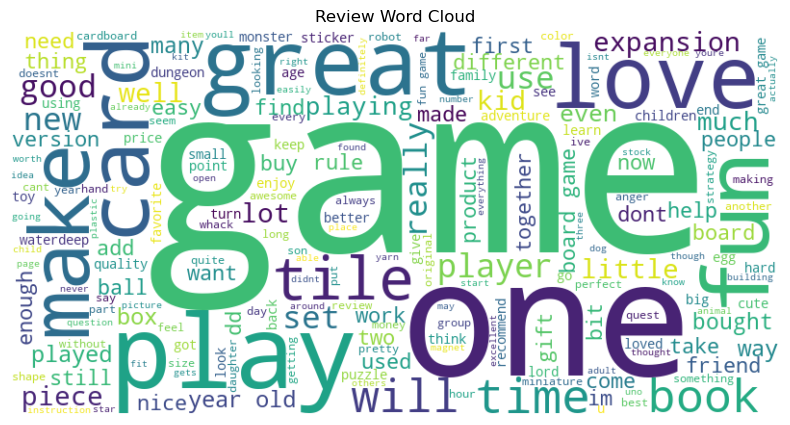

In [532]:
# Review: Plot the WordCloud image.
plt.figure(figsize=(10, 5))
plt.imshow(review_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud')
plt.show()

In [536]:
# Summary: Create a word cloud.
all_summary_words = ' '.join(df_tokenise['summary'].dropna())
summary_wc = WordCloud(width=800, height=400, background_color='white').generate(all_summary_words)


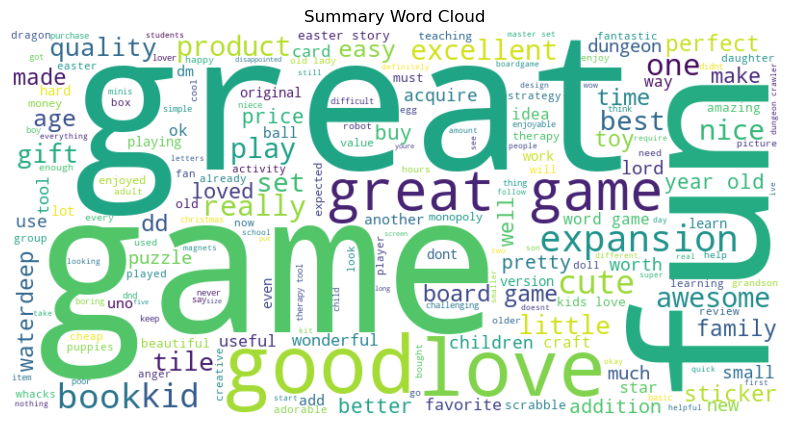

In [538]:
# Summary: Plot the WordCloud image.
plt.figure(figsize=(10, 5))
plt.imshow(summary_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Summary Word Cloud')
plt.show()

## 4. Frequency distribution and polarity
### 4a) Create frequency distribution

In [542]:
# Determine the frequency distribution.
review_words = [word for tokens in df_tokenise['review_tokens'] for word in tokens]
summary_words = [word for tokens in df_tokenise['summary_tokens'] for word in tokens]

review_freq = FreqDist(review_words)
summary_freq = FreqDist(summary_words)

print("Most common review words:")
print(review_freq.most_common(10))

print("\nMost common summary words:")
print(summary_freq.most_common(10))

Most common review words:
[('the', 5449), ('and', 3233), ('to', 3162), ('a', 3159), ('of', 2487), ('i', 2089), ('it', 2082), ('is', 1781), ('this', 1774), ('game', 1668)]

Most common summary words:
[('nan', 649), ('game', 268), ('the', 258), ('a', 238), ('great', 237), ('for', 229), ('to', 192), ('fun', 175), ('and', 168), ('it', 139)]


### 4b) Remove alphanumeric characters and stopwords

In [544]:
# Delete all the alpanum.
stop_words = set(stopwords.words('english'))

In [546]:
# Remove all the stopwords
clean_review_tokens = [word for word in review_words if word.isalpha() and word.lower() not in stop_words]
clean_summary_tokens = [word for word in summary_words if word.isalpha() and word.lower() not in stop_words]

### 4c) Create wordcloud without stopwords

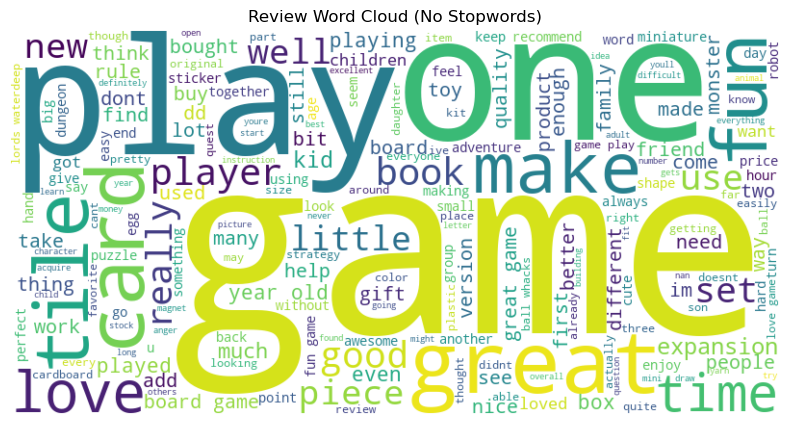

In [548]:
# Create a wordcloud without stop words.
clean_review_text = ' '.join(clean_review_tokens)
review_wc_clean = WordCloud(width=800, height=400, background_color='white').generate(clean_review_text)
plt.figure(figsize=(10, 5))
plt.imshow(review_wc_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Review Word Cloud (No Stopwords)')
plt.show()

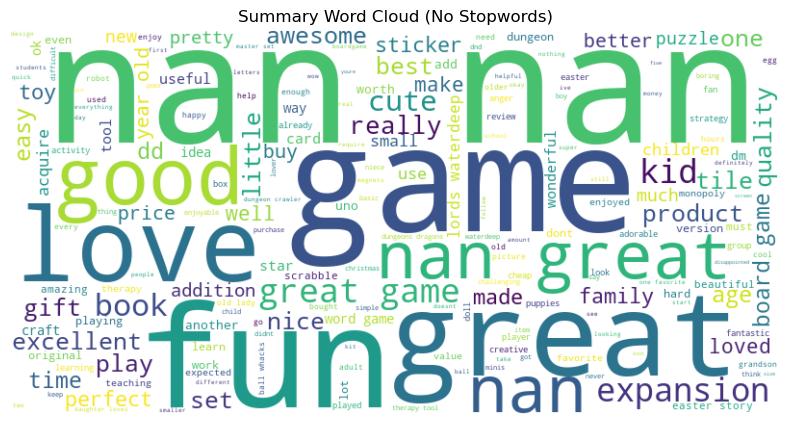

In [550]:
# Plot the wordcloud image.
clean_summary_text = ' '.join(clean_summary_tokens)
summary_wc_clean = WordCloud(width=800, height=400, background_color='white').generate(clean_summary_text)
plt.figure(figsize=(10, 5))
plt.imshow(summary_wc_clean, interpolation='bilinear')
plt.axis('off')
plt.title('Summary Word Cloud (No Stopwords)')
plt.show()

### 4d) Identify 15 most common words and polarity

In [552]:
# Determine the 15 most common words.
clean_review_freq = Counter(clean_review_tokens)
clean_summary_freq = Counter(clean_summary_tokens)

print("Top 15 Review Words (No Stopwords):")
print(clean_review_freq.most_common(15))

print("\nTop 15 Summary Words (No Stopwords):")
print(clean_summary_freq.most_common(15))

Top 15 Review Words (No Stopwords):
[('game', 1668), ('great', 579), ('fun', 549), ('one', 530), ('play', 502), ('like', 414), ('love', 322), ('really', 319), ('get', 319), ('cards', 301), ('tiles', 297), ('time', 291), ('good', 287), ('would', 280), ('book', 273)]

Top 15 Summary Words (No Stopwords):
[('nan', 649), ('game', 268), ('great', 237), ('fun', 175), ('good', 84), ('love', 70), ('like', 54), ('kids', 48), ('book', 42), ('expansion', 42), ('cute', 40), ('old', 34), ('really', 30), ('set', 30), ('nice', 28)]


## 5. Review polarity and sentiment: Plot histograms of polarity (use 15 bins) and sentiment scores for the respective columns.

In [562]:
# Provided function.
def generate_polarity(comment):
    '''Extract polarity score (-1 to +1) for each comment'''
    return TextBlob(comment).sentiment[0]

In [566]:
# Determine polarity of both columns. 
df_tokenise['review_polarity'] = df_tokenise['review'].astype(str).apply(generate_polarity)
df_tokenise['summary_polarity'] = df_tokenise['summary'].astype(str).apply(generate_polarity)

# View output.
df_tokenise[['review', 'review_polarity', 'summary', 'summary_polarity']].head()

,review,review_polarity,summary,summary_polarity
0,when it comes to a dms screen the space on the...,-0.036111,the fact that 50 of this space is wasted on ar...,0.15
1,an open letter to galeforce9 your unpainted m...,0.035952,another worthless dungeon masters screen from ...,-0.80
2,nice art nice printing why two panels are fil...,0.116640,pretty but also pretty useless,0.00
3,amazing buy bought it as a gift for our new dm...,0.578788,five stars,0.00
4,as my review of gf9s previous screens these we...,-0.316667,money trap,0.00


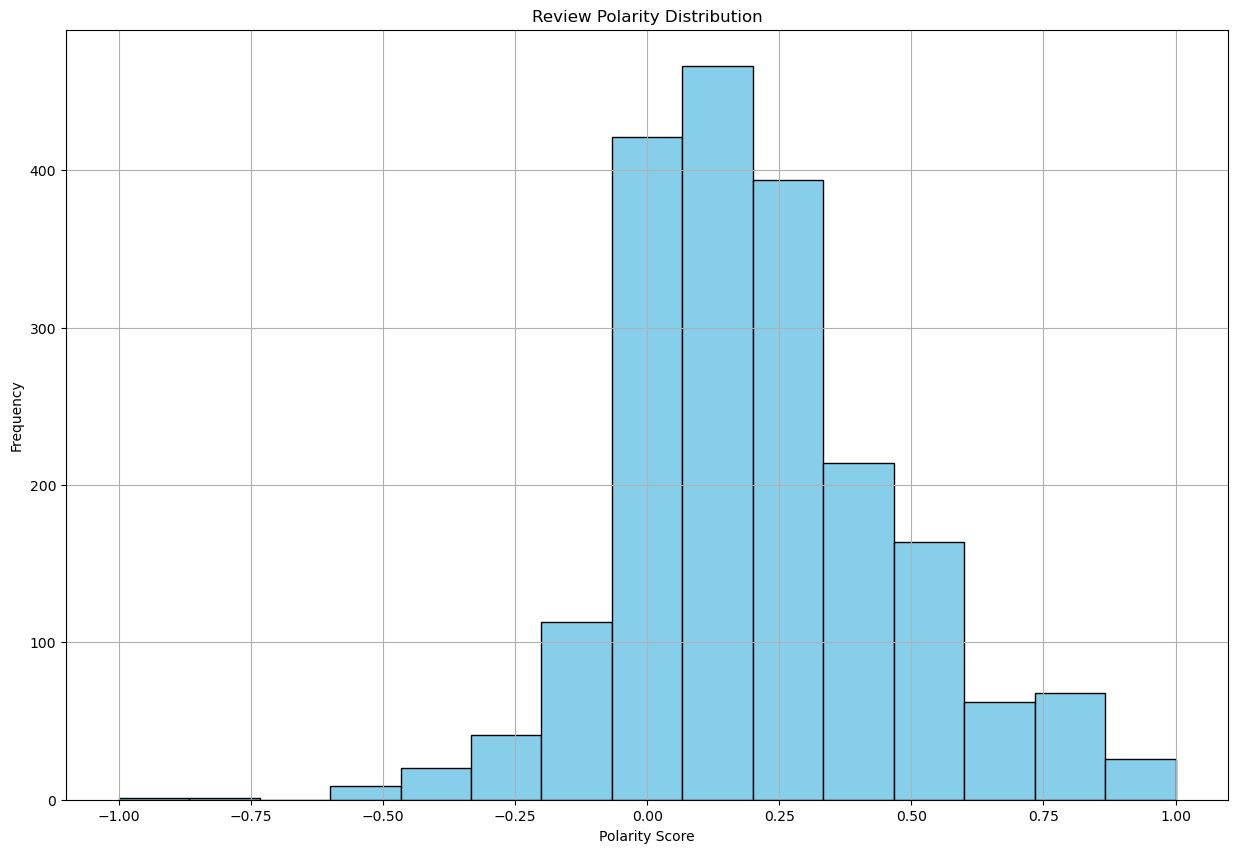

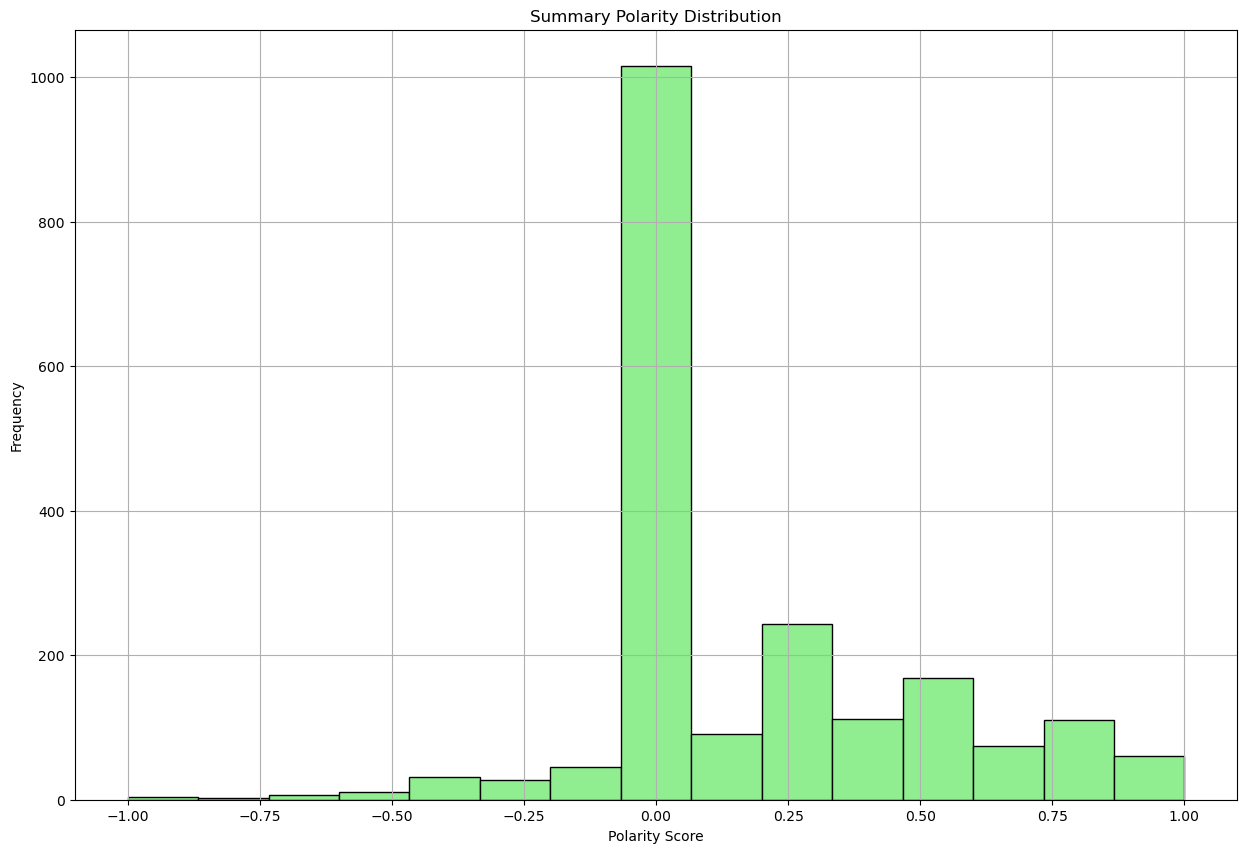

In [570]:
# Review: Create a histogram plot with bins = 15.
# Histogram of polarity
plt.hist(df_tokenise['review_polarity'], bins=15, color='skyblue', edgecolor='black')
plt.title('Review Polarity Distribution')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


# Histogram of sentiment score
plt.hist(df_tokenise['summary_polarity'], bins=15, color='lightgreen', edgecolor='black')
plt.title('Summary Polarity Distribution')
plt.xlabel('Polarity Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## 6. Identify top 20 positive and negative reviews and summaries respectively

In [576]:
# Top 20 negative reviews.
# View output.
print("Top 20 Negative Reviews:")
df_tokenise.sort_values(by='review_polarity').head(20)[['review', 'review_polarity']]

Top 20 Negative Reviews:


,review,review_polarity
208,booo unles you are patient know how to measur...,-1.000000
182,incomplete kit very disappointing,-0.780000
1804,im sorry i just find this product to be boring...,-0.583333
364,one of my staff will be using this game soon s...,-0.550000
1524,expensive for what you get,-0.500000
230,i found the directions difficult,-0.500000
117,i bought this as a christmas gift for my grand...,-0.500000
227,this was a gift for my daughter i found it di...,-0.500000
301,difficult,-0.500000
290,instructions are complicated to follow,-0.500000


In [578]:
# Top 20 negative summaries.
# View output.
print("Top 20 Negative Summaries:")
df_tokenise.sort_values(by='summary_polarity').head(20)[['summary', 'summary_polarity']]

Top 20 Negative Summaries:


,summary,summary_polarity
829,boring,-1.000000
208,boring unless you are a craft person which i am,-1.000000
21,the worst value ive ever seen,-1.000000
1166,before this i hated running any rpg campaign d...,-0.900000
1,another worthless dungeon masters screen from ...,-0.800000
144,disappointed,-0.750000
363,promotes anger instead of teaching calming met...,-0.700000
890,bad qualityall made of paper,-0.700000
885,too bad this is not what i was expecting,-0.700000
178,at age 31 i found these very difficult to make,-0.650000


In [580]:
# Top 20 positive reviews.
# View output.
print("Top 20 Positive Reviews:")
df_tokenise.sort_values(by='review_polarity', ascending=False).head(20)[['review', 'review_polarity']]

Top 20 Positive Reviews:


,review,review_polarity
1177,awesome addition to my rpg gm system,1.0
933,awesome,1.0
1550,my daughter loves her stickers awesome seller ...,1.0
496,excellent activity for teaching selfmanagement...,1.0
1301,its awesome,1.0
194,awesome gift,1.0
1135,awesome set,1.0
1715,awesome toy,1.0
609,delightful product,1.0
1967,perfect for tutoring my grandson in spelling,1.0


In [582]:
# Top 20 positive summaries.
# View output.
print("Top 20 Positive Summaries:")
df_tokenise.sort_values(by='summary_polarity', ascending=False).head(20)[['summary', 'summary_polarity']]


Top 20 Positive Summaries:


,summary,summary_polarity
1427,excellent expansion,1.0
140,awesome sticker activity for the price,1.0
651,all f the mudpuppy toys are wonderful,1.0
1543,loves stickers and she loves peppa so this wa...,1.0
1388,awesome expansion,1.0
870,one of the best,1.0
1488,the perfect gift for preschool construction fans,1.0
980,the best among the dd boardgames,1.0
724,excellent puzzle,1.0
187,awesome,1.0


## 7. Discuss: Insights and observations

***Your observations here...***

- Sentiment in both reviews and the summary of reviews are positive to slgihtly positive.
- Nan is a keyword in sumarry showing that nans are likely to play - or enjoy the game.
- A theme for reviews where the polarity is extremely negative is that the game might be 'boring'

# 